In [360]:
#importing required libraries
import numpy as np
import pandas as pd

import os
import sys

#importing current dataset
path='/home/dreams/Projects/webScraping/MachineLearningProject/IntroductionMachineLearning/dataset/ExamScorePrediction/Exam_Score_Prediction.csv'
dataset=pd.read_csv(path)

#creating Two dataFrame
# categoricalDf=pd.DataFrame(
#     data={
#         ''
#     }
# )
df=pd.DataFrame(dataset)
# categoricalDf=df[df.columns.astype=='object']
# categoricalDf=df[df.columns.dtype=='object']
# defining filter
filter_=df.columns[df.dtypes=='object']
categoricalDf=df[filter_]

# print('categorical dataFrame')
# print(categoricalDf)

#creating dataFrame that only includes numerical values.
filter_=df.columns[(df.dtypes==np.int64)|(df.dtypes==np.float64)]
numericalDf=df[filter_]
numericalDf.columns
numericalDf=numericalDf.drop(['student_id'],axis=1)
# numericalDf.describe()


#creating dataFrame that only includes categorical values.
#definin mask.
mask=df.dtypes==np.object_
# print(mask)
categoricalDf=df[df.columns[mask]]
categoricalDf.describe()
# print(type(categoricalDf))

,gender,course,internet_access,sleep_quality,study_method,facility_rating,exam_difficulty
count,20000,20000,20000,20000,20000,20000,20000
unique,3,7,2,3,5,3,3
top,other,bca,yes,average,self-study,medium,moderate
freq,6726,2902,16988,6694,4079,6760,9878


In [361]:
# print('removed nan values')
# #Remove duplicates and inconsistent values
# numericalDf=numericalDf.dropna()
# ##Remove duplicates
# numericalDf=numericalDf.value.unique()
# # numericalDf.loc[:][:].unique()

#defining function removing duplicates and inconsistent values
def meanImputation(df:pd.Series)->None:
    try:
        #using imputation techniques
        ##Called Mean/Median Imputation
        # df=df.fillna()
        meanValue=np.nanmean(df)
        df=np.where(df.isna(),meanValue,df) #np.ndarray

        # return df
     


    except ValueError:
        raise Exception ('it gotta problem with your ARRAY SHAPE!!!')

    except Exception as e:
        return '{}'.format(e)
    

def modeImputation(df:pd.Series)->None:
    try:
        # importing required libraries
        import numpy as np
        from collections import Counter
        
        #filtering non-None value
        mask=[data for data in df if data is not None]

        #Remove None Values
        modeValue=Counter(mask).most_common(1)[0][0]

        #revising current dataframe with imputed data   
        df=np.array([x if x is not None else modeValue for x in mask],
                    dtype=object)
        
        return df

    except ValueError:
        raise Exception('it gotta problem with your ARRAY SHAPE!!!')
    
    except Exception as e:
        return '{}'.format(e)



#traversing through columns and clean current dataFrames.
numericalDf.reset_index(drop=True)
categoricalDf.reset_index(drop=True)
for ele in df.columns:

    #Original version
    # checking df 
    if hasattr(categoricalDf,ele):
        #mode Imputation
        categoricalDf.loc[:,ele]=modeImputation(categoricalDf[ele])
        # print("mode imputation is completed:\t{}".format(ele))
        continue
    if hasattr(numericalDf,ele):
        #mean Imputation
        numericalDf.loc[:,ele]=meanImputation(numericalDf[ele])
        # print("mean imputation is completed:\t{}".format(ele))
        continue
    
    ##optimized version
    # if ele in categoricalDf.columns:
    #     modeImputation(categoricalDf[ele])
    #     print("mode imputation is completed:\t{}".format(ele))

    # if ele in numericalDf.columns:
    #     meanImputation(numericalDf[ele])
    #     print('mean imputation is completed:\t{}'.format(ele))

print('Cleaned and revised current dataFrames')
# numericalDf.describe()
categoricalDf.describe()


Cleaned and revised current dataFrames


/tmp/ipykernel_94918/1546608181.py:68: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value 'None' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  numericalDf.loc[:,ele]=meanImputation(numericalDf[ele])
/tmp/ipykernel_94918/1546608181.py:68: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value 'None' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  numericalDf.loc[:,ele]=meanImputation(numericalDf[ele])
/tmp/ipykernel_94918/1546608181.py:68: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value 'None' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  numericalDf.loc[:,ele]=meanImputation(numericalDf[ele])
/tmp/ipykernel_94918/1546608181.py:68: FutureWarning: Setting an item of

,gender,course,internet_access,sleep_quality,study_method,facility_rating,exam_difficulty
count,20000,20000,20000,20000,20000,20000,20000
unique,3,7,2,3,5,3,3
top,other,bca,yes,average,self-study,medium,moderate
freq,6726,2902,16988,6694,4079,6760,9878


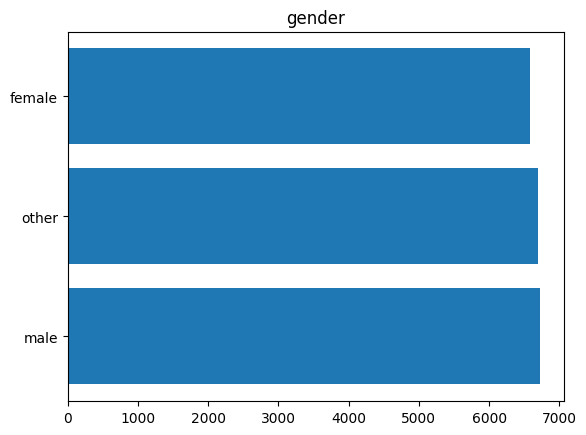

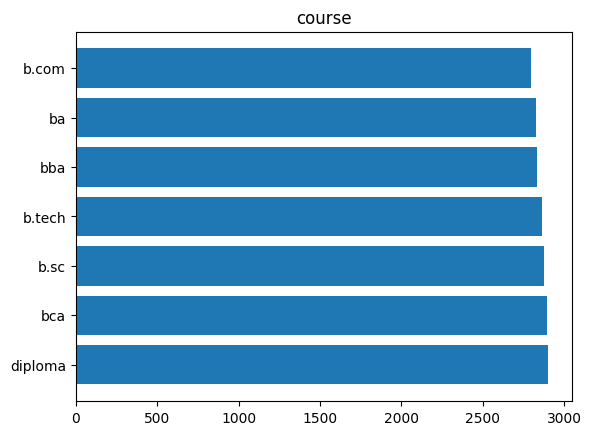

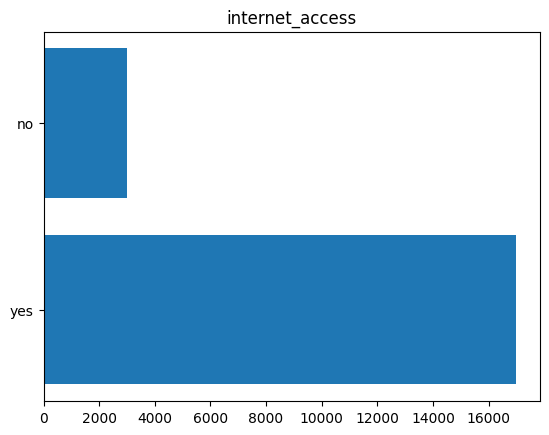

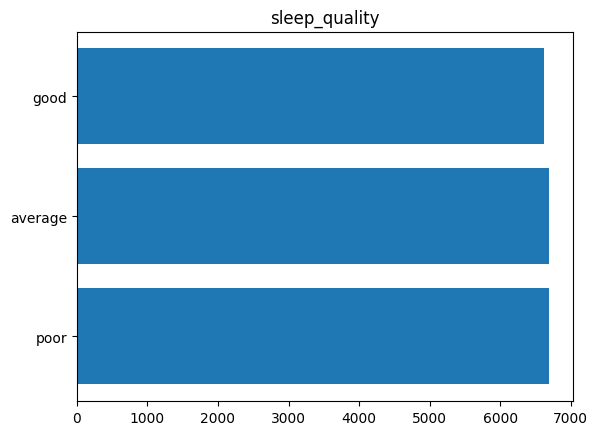

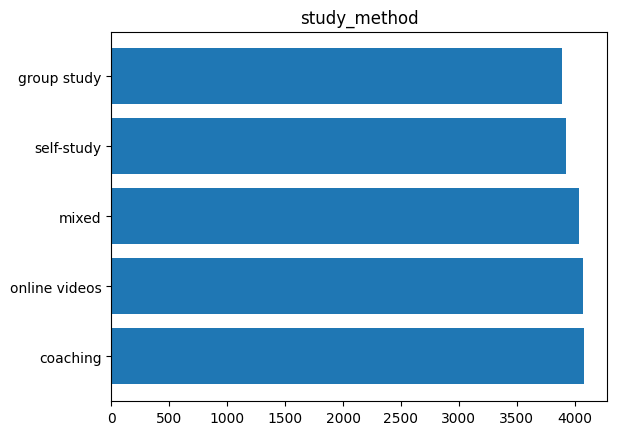

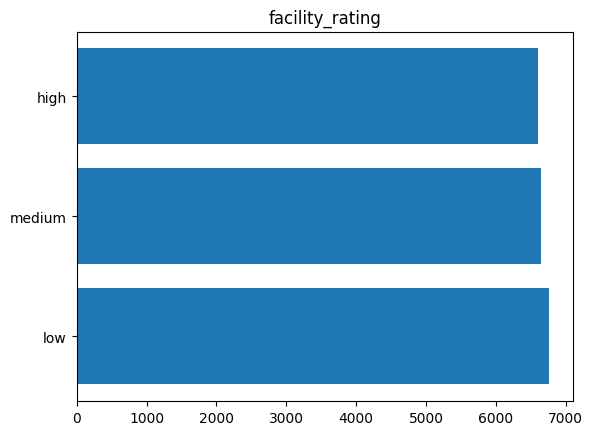

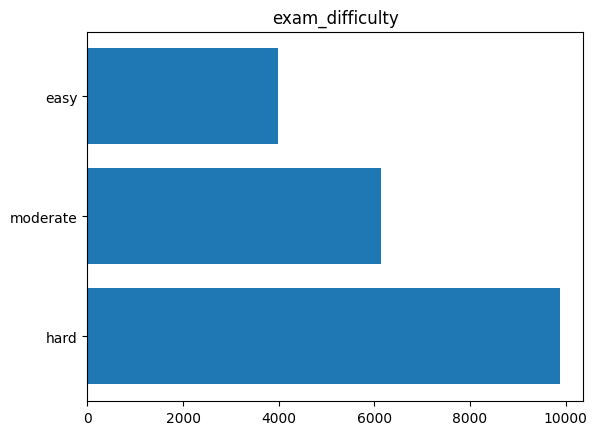

In [362]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns


# categoricalDf.count().plot.barh()

# categoricalDf['exam_difficulty'].T.value_counts().plot.barh()
import matplotlib.pyplot as plt
import seaborn as sns

for categorical in categoricalDf.columns:
    # categoricalDf[categorical].T.value_counts().plot.barh()
    valueCounts=categoricalDf[categorical].T.value_counts()
    # print(valueCounts)
    plt.barh(categoricalDf[categorical].T.unique(),valueCounts)
    plt.title(categorical)
    plt.show()
    
    

In [363]:
from scipy.stats import chi2_contingency
# chi,p,dof,expected=chi2_contingency(courseCrossTab)
# print(chi)
# print(p)
# print(dof)
# print(expected)

df=pd.DataFrame()
alpha=0.05

# print(variables)
# print(type(categoricalDf[categoricalDf.columns[filter_]]))
for column in categoricalDf.columns:
    _,p,_,_=chi2_contingency(pd.crosstab(
        categoricalDf['course'],categoricalDf[column]
        ))
    if alpha<p:
        print(f"{column}:\tThe two variables are independent (there is no assocoation between them).rejected")
    else:
        print(f'{column}:\tThe two variables are dependent(there is an association between them).Accepted')
    df=pd.concat([df,pd.DataFrame(data={column:[p]})],axis=1)


print(df)

gender:	The two variables are dependent(there is an association between them).Accepted
course:	The two variables are dependent(there is an association between them).Accepted
internet_access:	The two variables are independent (there is no assocoation between them).rejected
sleep_quality:	The two variables are independent (there is no assocoation between them).rejected
study_method:	The two variables are independent (there is no assocoation between them).rejected
facility_rating:	The two variables are independent (there is no assocoation between them).rejected
exam_difficulty:	The two variables are independent (there is no assocoation between them).rejected
     gender  course  internet_access  sleep_quality  study_method  \
0  0.037142     0.0         0.777794       0.708709      0.807399   

   facility_rating  exam_difficulty  
0         0.806377         0.695298  


In [ ]:
import pandas as pd
import numpy as np

toFullName={
    'b.tech':'bioTechnology',
    'diploma':'diploma',
    'bba':'computerScience',
    'b.com':'computerEngineering',
    'b.sc':'electiricEngineering',
    'ba':'electronicEngineering',
    'bca':'bioEngineering',

}
# categoricalDf.columns=[toFullName.values()]

# print(categoricalDf.columns)
# print(categoricalDf['course'].values)
# print(categoricalDf.columns)



# #rename columns course abbr to full name
def toCourseFullName(df:pd.Series)->pd.Series: 
   
    categories=df.unique()
    print(categories)
    for category in categories:
    #     # print("===================")
    #     # print("===================")
    #     # print(category)
    #     print(toFullName[category])
        mask=(df==category)
    #     # print(mask)
        df.loc[mask]=toFullName[category]
    #     # print(categoricalDf.loc[mask])
    #     # print("===================")
    #     # print("===================")
    
    print('converted all abbr to full name')

categoricalDf.columns=categoricalDf.columns.str.replace(' ','')

# course code converts to full name
# toCourseFullName(categoricalDf['course'])
# categoricalDf.T
#encoding all categorical features
def encoding(df:pd.DataFrame):
    # dividing nominal and ordinal features.
    # for column in df.columns:
        # print(f'{column}:{df[column].T.unique()}')
        ##return columns data



    # ColumnTransformer is used to combine multiple encoders into
    #a single step and apply them to the aprropriate columns
    #defining Ordinal data
    ordinalFeatures=[ 'internet_access', 'sleep_quality', 'facility_rating', 'exam_difficulty']
    #defining Nominal data 
    nominalFeatures=['gender', 'course','study_method']
    # print(categoricalDf.columns)
    #Ordinal Encoding
    #OneHotEncoding
    # defining libraries
    import pandas as pd
    from sklearn.preprocessing import OrdinalEncoder
    from sklearn.preprocessing import OneHotEncoder
 
    orEncoder=OrdinalEncoder()
    # categoricalDf.loc[ordinalFeatures]=orEncoder.fit_transform(categoricalDf[ordinalFeatures])

    

    nomEncoder=OneHotEncoder(sparse_output=False)

    # print(nomEncoder)
    # print(orEncoder)
    # print(categoricalEncoder)
    # abc=nomEncoder.fit_transform(categoricalDf[nominalFeatures])
    # print(abc)
    # bcd=orEncoder.fit_transform(categoricalDf[ordinalFeatures])
    # print(bcd)
    ###Worked###
    from sklearn.compose import ColumnTransformer
    import numpy as np
    ct=ColumnTransformer(
        transformers=[
            ('ord',orEncoder,ordinalFeatures),
            ('oneHot',nomEncoder,nominalFeatures)
        ]
    )
    ct.set_output(transform='pandas')
    encodedFeatures=ct.fit_transform(df)
    encodedFeatures=encodedFeatures.astype(np.int64)
    # categoricalDf=pd.concat(encodedFeatures,axis=1)
    
    # return categoricalDf
    # encodedFeatures.to_csv('attempt.csv')
    # print(encodedFeatures)
    return encodedFeatures

toCourseFullName(categoricalDf['course'])

categoricalDf=encoding(categoricalDf)
# print(encodedFeatures)
# print(categoricalDf.columns)
# categoricalDf=modeImputation(categoricalDf)
# numericalDf=meanImputation(numericalDf)
for category in categoricalDf.columns:
    categoricalDf.loc[:,category]=modeImputation(categoricalDf[category])

for category in numericalDf.columns:
    numericalDf.loc[:,category]=meanImputation(numericalDf[category])

['diploma' 'bca' 'b.sc' 'b.tech' 'bba' 'ba' 'b.com']
converted all abbr to full name


/tmp/ipykernel_94918/3791719416.py:110: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[1 1 1 ... 1 0 1]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  categoricalDf.loc[:,category]=modeImputation(categoricalDf[category])
/tmp/ipykernel_94918/3791719416.py:110: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[2 0 2 ... 2 1 2]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  categoricalDf.loc[:,category]=modeImputation(categoricalDf[category])
/tmp/ipykernel_94918/3791719416.py:110: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[1 2 0 ... 1 2 2]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  categoricalDf.loc[:,category]=modeImputation(categoricalDf[cat

Text(0.5, 0, 'Categorical Features')

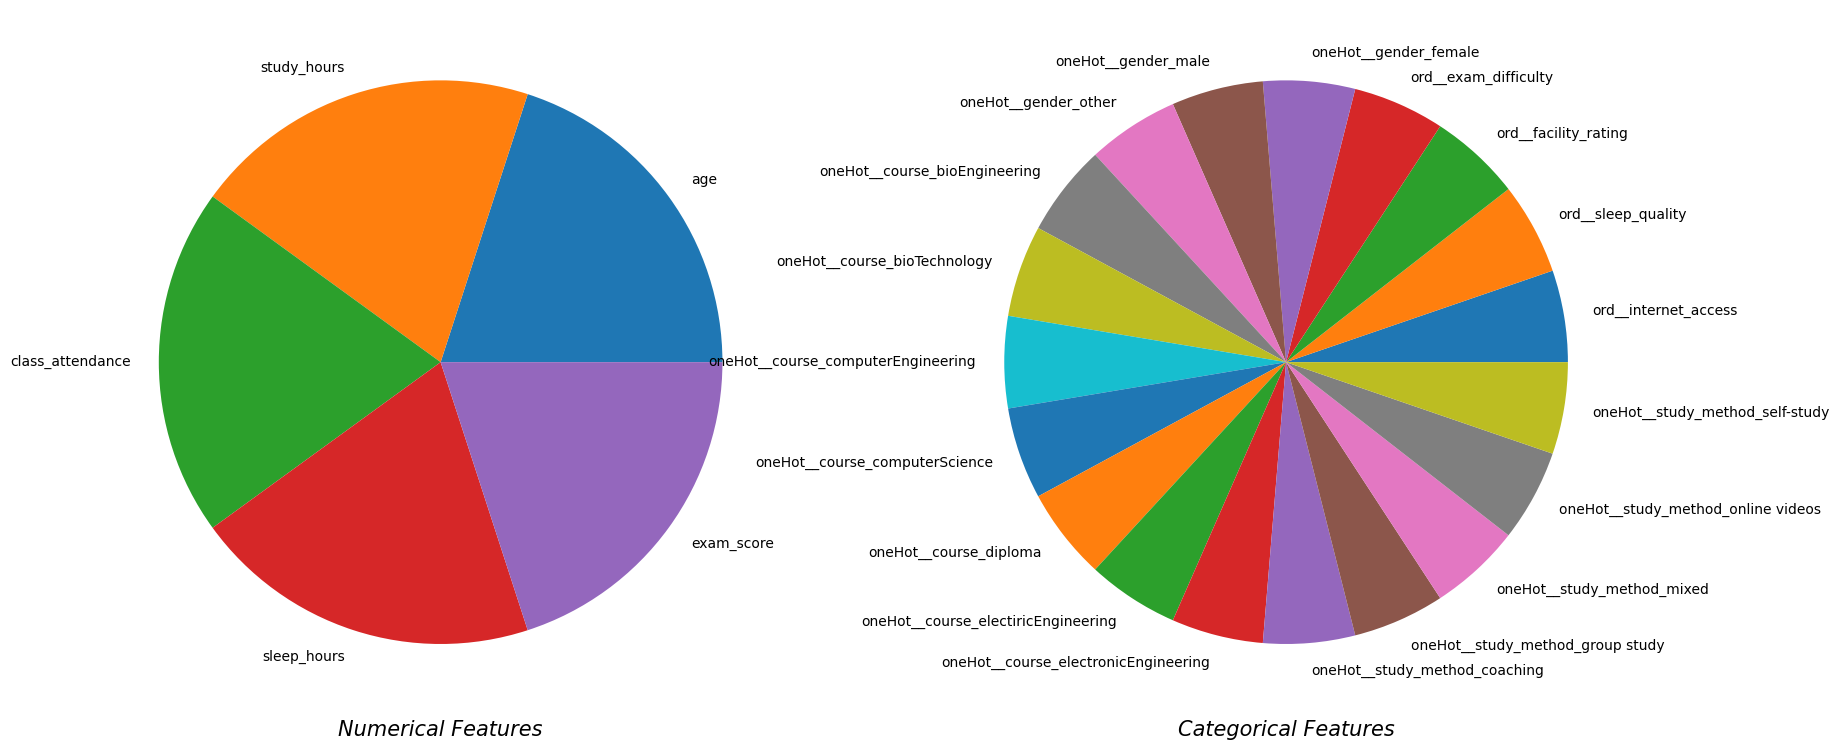

In [365]:
%matplotlib inline
import matplotlib.pyplot as plt
# numericalDf.count().plot.pie()
# # numericalDf.count()
# categoricalDf.count().plot.pie()
# # categoricalDf.value_counts().plot.pie()
# fig,axes=plt.subplots(figsize=(12,12))


font={
    'color':'black',
    'size':'15',
    'style':'oblique'

}
fig,axes=plt.subplots(1,2,sharex=False,sharey=False,figsize=(20,20))
ax1,ax2=axes.flatten()


numericalDf.count().plot.pie(ax=ax1)
categoricalDf.count().plot.pie(ax=ax2)


ax1.set_xlabel('Numerical Features',fontdict=font)
ax2.set_xlabel('Categorical Features',fontdict=font)

# ax1.pie(numericalDf.count(),ax1)
# ax2.pie(categoricalDf.count())




# print(hasattr(axes,'flatten'))
# print(hasattr(axes,'flat'))
# print(dir(axes))





<Axes: >

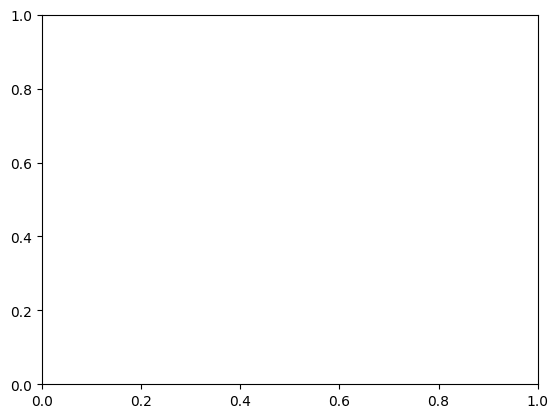

In [366]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

sns.boxplot(numericalDf)

In [367]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

# fig,axes=plt.subplots(1,2,figsize=(12,12),sharex=False,sharey=False)
# ax1,ax2=axes.flatten()
sns.pairplot(numericalDf)
# plt.figsize((10,10))
plt.title('numerical Features')
plt.show()

ValueError: No variables found for grid columns.

<Axes: ylabel='Frequency'>

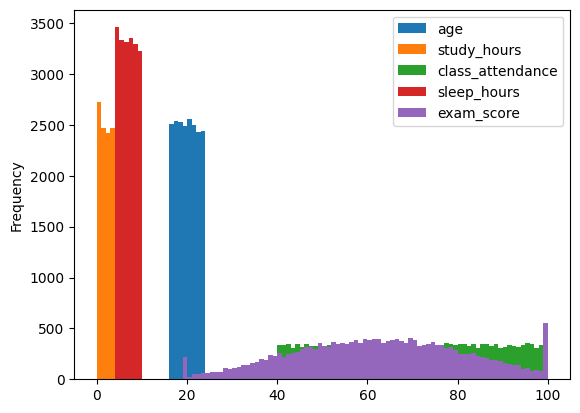

In [ ]:
numericalDf.plot.hist(bins=100)

Text(0, 0.5, 'Frequency')

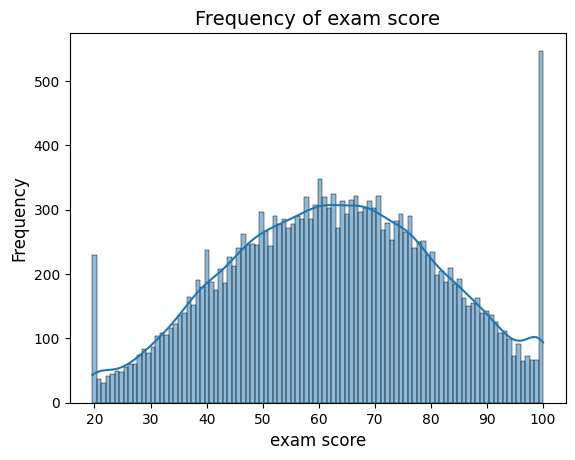

In [ ]:
# numericalDf['exam_score'].plot.hist(bins=100)
import matplotlib.pyplot as plt
import seaborn as sns

#defining histplot 
sns.histplot(numericalDf['exam_score'],bins=100,kde=True)

#revising axes
plt.title('Frequency of exam score',fontsize=14)
plt.xlabel('exam score',fontsize=12)
plt.ylabel('Frequency',fontsize=12)

#Poisson distribution


<Axes: xlabel='exam_score'>

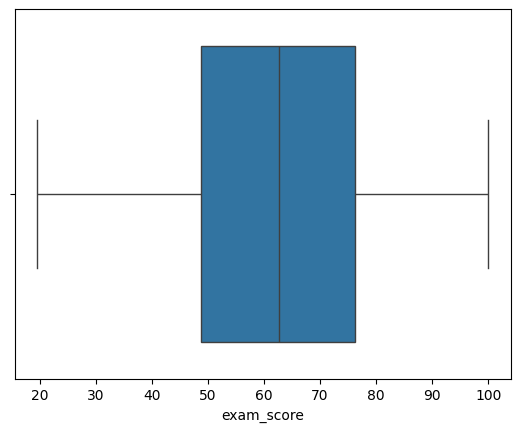

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.boxplot(x=numericalDf['exam_score'])

<Axes: xlabel='study_hours', ylabel='Count'>

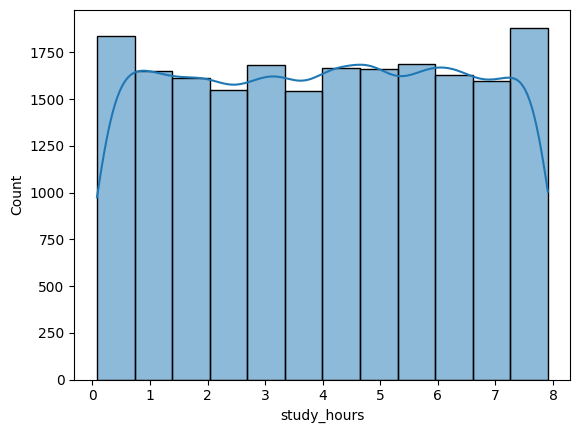

In [ ]:
# numericalDf['study_hours'].plot.hist(bins=10,color='green')
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(numericalDf['study_hours'],kde=True,bins=12)



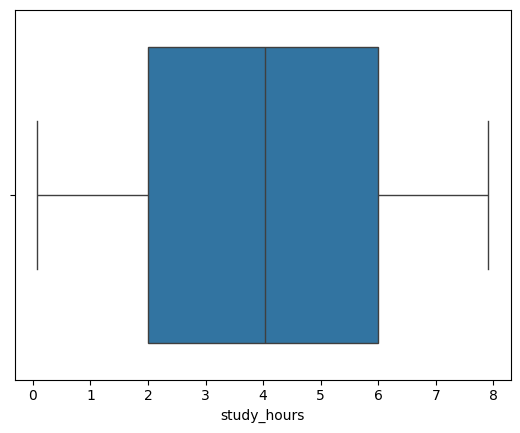

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.boxplot(x=numericalDf['study_hours'])
plt.show()

<Axes: xlabel='class_attendance', ylabel='Count'>

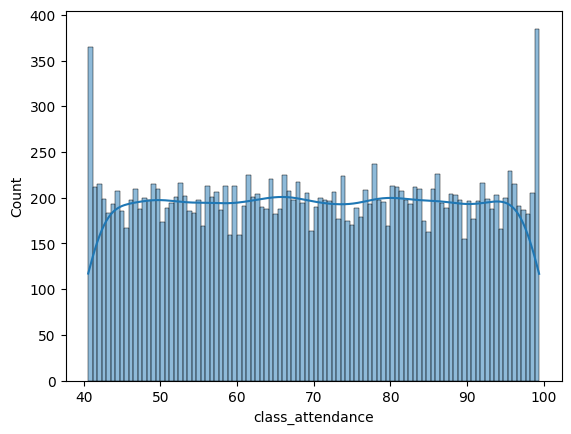

In [ ]:
# numericalDf['class_attendance'].plot.hist(bins=100,color='green')
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(numericalDf['class_attendance'],bins=100,kde=True)



<Axes: xlabel='class_attendance'>

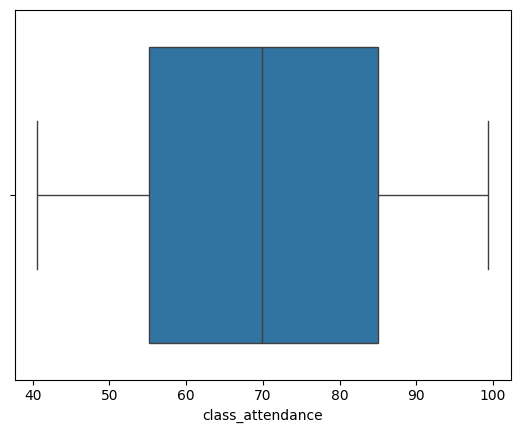

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.boxplot(x=numericalDf['class_attendance'])

<Axes: xlabel='age', ylabel='Count'>

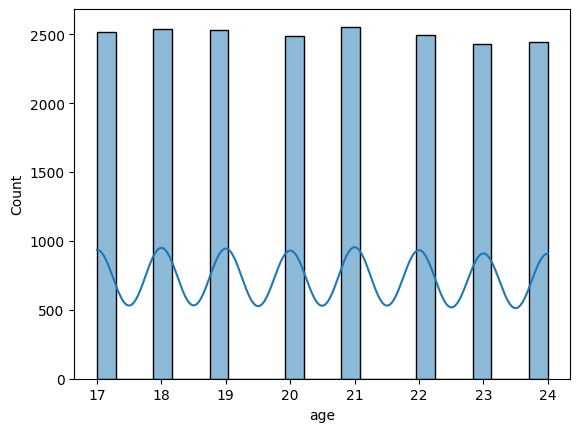

In [ ]:
#age,sleep_hours
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(numericalDf['age'],kde=True)
# sns.countplot(numericalDf['age'])

<Axes: xlabel='age'>

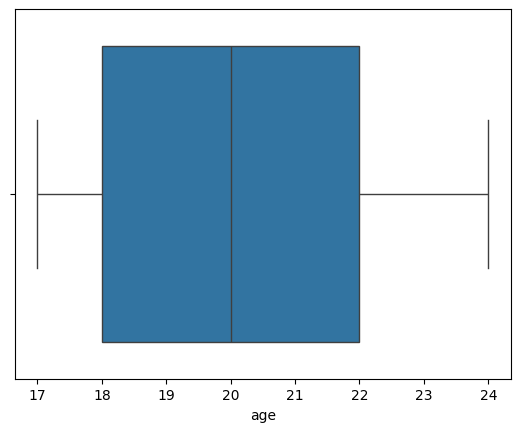

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.boxplot(x=numericalDf['age'])

<Axes: xlabel='sleep_hours', ylabel='Count'>

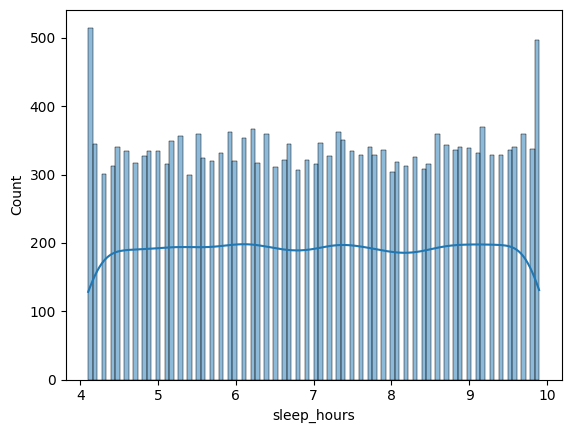

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(numericalDf['sleep_hours'],bins=100,kde=True)

<Axes: xlabel='sleep_hours'>

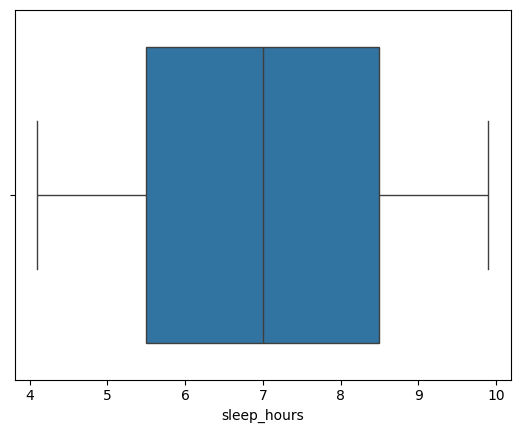

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.boxplot(x=numericalDf['sleep_hours'])

/tmp/ipykernel_94918/2738831783.py:35: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-1.54605809  1.10151722  0.67799644 ... -0.63328636 -0.63328636
 -0.18897938]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  numericalDf.loc[:,'age']=pt.fit_transform(numericalDf.loc[:,'age'].values.reshape(-1,1))


<Axes: >

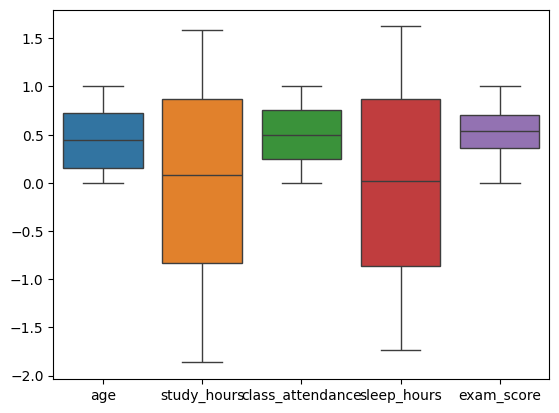

In [ ]:
import matplotlib.pyplot as plt
# numericalDf.sum().plot.pie()
# numericalDf.plot.hist(bins=100)

# numericalDf.sum().plot.pie()
# numericalDf.plot.hist(bins=100)


##do minmaxScaler normalization sleep_hours,age and study_hours  columns 
def dataNormalization(df:pd.Series)->None:
    pass

def featureSelection(df:pd.DataFrame):
      pass


# new=pd.concat([numericalDf['exam_score'],numericalDf['class_attendance']],axis=1).values.reshape((40000, 1))


import seaborn as sns
import matplotlib.pyplot as plt

# sns.boxplot([np.ravel(new),numericalDf['age'],numericalDf['study_hours'],numericalDf['sleep_hours']])
# sns.histplot([np.ravel(new),numericalDf['age'],numericalDf['study_hours'],numericalDf['sleep_hours']])

#applying MinMaxScaler age ,study_hours and sleep_hours

from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler #Z-score normalization


from sklearn.preprocessing import PowerTransformer
#X is the dataset ( as a NumPy array or DataFrame)
pt=PowerTransformer(method='yeo-johnson')
numericalDf.loc[:,'age']=pt.fit_transform(numericalDf.loc[:,'age'].values.reshape(-1,1))
numericalDf.loc[:,'study_hours']=pt.fit_transform(numericalDf.loc[:,'study_hours'].values.reshape(-1,1))
numericalDf.loc[:,'sleep_hours']=pt.fit_transform(numericalDf.loc[:,'sleep_hours'].values.reshape(-1,1))

minmax=MinMaxScaler()
numericalDf.loc[:,'exam_score']=minmax.fit_transform(numericalDf.loc[:,'exam_score'].values.reshape(-1,1))
numericalDf.loc[:,'class_attendance']=minmax.fit_transform(numericalDf.loc[:,'class_attendance'].values.reshape(-1,1))
numericalDf.loc[:,'age']=minmax.fit_transform(numericalDf.loc[:,'age'].values.reshape(-1,1))

# numericalDf.loc[:,'age']=minmax.fit_transform(numericalDf.loc[:,'age'].values.reshape(-1,1))
# numericalDf.loc[:,'age']=np.log(numericalDf.loc[:,'age'])


# sns.histplot([np.ravel(new),numericalDf['sleep_hours'],numericalDf['study_hours'],numericalDf['age']]

sns.boxplot(numericalDf)

# sns.histplot(numericalDf)





<Axes: ylabel='Count'>

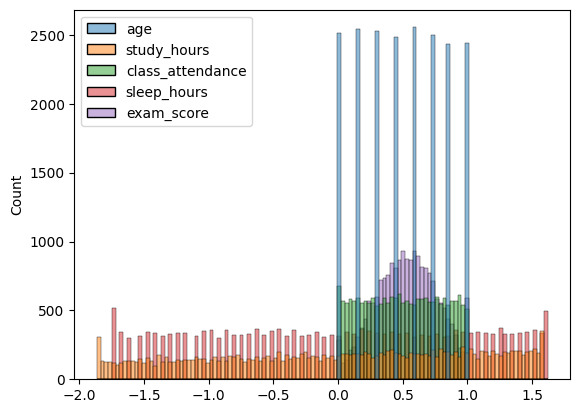

In [ ]:
sns.histplot(numericalDf)

<Axes: >

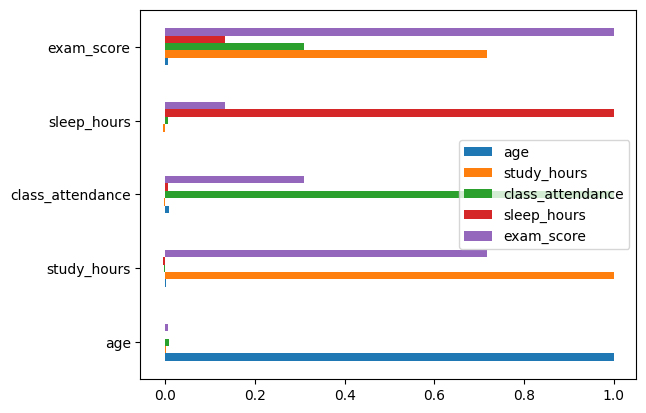

In [ ]:
##Feature Selection Pearson's Correalition coefficient
#Feature Selection Pearson's Correlation Coefficient:f_regression()
##pearson for numericalDf DataFrame
numericalDf.corr(method='pearson').plot.barh()
##Chi-Square data analysis for categoricalDf DataFrame

#Creating a Contigency Table(cross-tab)
# courseCrossTab=pd.crosstab(categoricalDf['course'],categoricalDf['gender'],
#                            margins=True,margins_name='subtotal')



In [ ]:
print(categoricalDf.columns)

Index(['ord__internet_access', 'ord__sleep_quality', 'ord__facility_rating',
       'ord__exam_difficulty', 'oneHot__gender_female', 'oneHot__gender_male',
       'oneHot__gender_other', 'oneHot__course_bioEngineering',
       'oneHot__course_bioTechnology', 'oneHot__course_computerEngineering',
       'oneHot__course_computerScience', 'oneHot__course_diploma',
       'oneHot__course_electiricEngineering',
       'oneHot__course_electronicEngineering', 'oneHot__study_method_coaching',
       'oneHot__study_method_group study', 'oneHot__study_method_mixed',
       'oneHot__study_method_online videos',
       'oneHot__study_method_self-study'],
      dtype='object')


In [ ]:
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import ElasticNet,Lasso
from sklearn.multiclass import  OneVsRestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split


selectedNumericalFeatures=['study_hours','class_attendance','sleep_hours']
filter_=categoricalDf.columns.str.startswith('oneHot')
selectedCategoricalFeature=categoricalDf[categoricalDf.columns[~filter_]]
X=numericalDf[selectedNumericalFeatures]+selectedCategoricalFeature
y=categoricalDf[categoricalDf.columns[~filter_]]

from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test=train_test_split(X,y,random_state=42,test_size=0.33)

print("Train:\t",X_train.shape,Y_train.shape)
print("Test:\t",X_test.shape,Y_test.shape)

# model=make_pipeline(
#     ElasticNet(random_state=0),
#     OneVsRestClassifier(SVC())
# )
# model.fit(X_train,Y_train)
# print(pred)
# pred=model.predict(X_test)


# model=make_pipeline(
#     ElasticNet(random_state=42),
# )

# from sklearn.linear_model import LogisticRegression
# model=make_pipeline(
#     LogisticRegression(multi_class='ovr',penalty='',solver=''),
# )

from sklearn.linear_model import LogisticRegression
model=make_pipeline(
    LogisticRegression(penalty='elasticnet',solver='saga',l1_ratio=0.5)
) ##classsification report precision:0.14 i have tried all solvers and penalties


Train:	 (13400, 7) (13400, 4)
Test:	 (6600, 7) (6600, 4)


In [ ]:
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score
model.fit(X_train,Y_train)
pred=model.predict(X_test)
print(classification_report(Y_test,pred))
print(confusion_matrix(Y_test,pred))
print(accuracy_score(Y_test,pred))

ValueError: Input X contains NaN.
LogisticRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [ ]:

# from sklearn.metrics import r2_score
# from sklearn.metrics import mean_squared_error

# rmse = np.sqrt(mean_squared_error(Y_test, pred))
# rel_rmse = rmse / np.mean(Y_test) * 100
# r2=r2_score(Y_test,pred)
# acc=model.score(X_test,Y_test)

# print(f"RMSE: {rmse:.3f} ({rel_rmse:.2f}%)")
# print(f"R2 score:{r2:.3f}")
# print(f"Accuracy:{acc:.3f}")
